# 07 — Resolution-Matched Control Experiment

**Milestone 6** (August 2026)

Every generalisation evaluation pairs high-resolution generator fakes with CIFAKE
`test/REAL` images (32×32 upscaled to 224). Resolution is therefore confounded with
the class label. This notebook runs a 2×2 control to test whether the detector is
separating **resampling signatures** rather than **generator artefacts**.

| Condition | Images | Pipeline | Question |
|-----------|--------|----------|----------|
| **A** | CIFAKE REAL | Native (`Resize(256)` + `CenterCrop(224)`) | Reference real FAKE-rate |
| **B** | High-res real photos (COCO / matched-source) | Native | Do high-res reals trigger false positives? |
| **C** | Same high-res reals | Force 32×32, then native | Isolates resolution with content held fixed |
| **D** | Generator FAKEs (5 families) | Force 32×32, then native | Does fake detection survive resolution matching? |

**Interpretation:**
- High FAKE-rate in **B** → resolution confound; the 94–97% generalisation figures are inflated.
- Low FAKE-rate in **B** (comparable to **A**) → detector genuinely transfers; confound ruled out.


## 0. Colab Setup

In [1]:
# Cell 1 — Mount Google Drive & define paths
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DRIVE_ROOT = "/content/drive/MyDrive/ai-image-detection"
    REPO_DIR = "/content/ai-image-detection"
    DATA_DIR = os.path.join(REPO_DIR, "data", "raw", "cifake")
    CHECKPOINT_DIR = os.path.join(DRIVE_ROOT, "checkpoints")
    OUTPUT_DIR = os.path.join(DRIVE_ROOT, "outputs")
    GEN_DIR = os.path.join(DRIVE_ROOT, "data", "generalisation")
    CONTROLS_DIR = os.path.join(GEN_DIR, "_controls")

    os.makedirs(DRIVE_ROOT, exist_ok=True)
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    if not os.path.exists(REPO_DIR):
        !git clone https://github.com/krishi-shah/ai-image-detection.git {REPO_DIR}
    else:
        print(f"Repo already present at {REPO_DIR}")
else:
    REPO_DIR = str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
    DRIVE_ROOT = REPO_DIR
    DATA_DIR = os.path.join(REPO_DIR, "data", "raw", "cifake")
    CHECKPOINT_DIR = os.path.join(REPO_DIR, "outputs", "checkpoints")
    OUTPUT_DIR = os.path.join(REPO_DIR, "outputs")
    GEN_DIR = os.path.join(REPO_DIR, "data", "generalisation")
    CONTROLS_DIR = os.path.join(GEN_DIR, "_controls")

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")
print(f"Data directory:    {DATA_DIR}")
print(f"Checkpoint dir:    {CHECKPOINT_DIR}")
print(f"Controls dir:      {CONTROLS_DIR}")
print(f"Output dir:        {OUTPUT_DIR}")


Mounted at /content/drive
Cloning into '/content/ai-image-detection'...
remote: Enumerating objects: 461, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 461 (delta 0), reused 0 (delta 0), pack-reused 459 (from 1)
Receiving objects: 100% (461/461), 36.61 MiB | 18.42 MiB/s, done.
Resolving deltas: 100% (130/130), done.
Working directory: /content/ai-image-detection
Data directory:    /content/ai-image-detection/data/raw/cifake
Checkpoint dir:    /content/drive/MyDrive/ai-image-detection/checkpoints
Controls dir:      /content/drive/MyDrive/ai-image-detection/data/generalisation/_controls
Output dir:        /content/drive/MyDrive/ai-image-detection/outputs


In [2]:
# Cell 2 — Install dependencies
!pip install -q -r requirements.txt


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 118.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.7/87.7 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.5/63.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.6/325.6 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 94.7 MB/s eta

In [3]:
# Cell 3 — Extract CIFAKE from Drive zip (Colab only)
import os, zipfile, glob

os.makedirs(DATA_DIR, exist_ok=True)

if os.path.exists(os.path.join(DATA_DIR, "train")):
    print("CIFAKE already extracted — skipping.")
else:
    zip_candidates = glob.glob(os.path.join(DRIVE_ROOT, "*.zip"))
    if not zip_candidates:
        raise FileNotFoundError(
            f"No .zip found in {DRIVE_ROOT}. Upload the CIFAKE archive there first."
        )
    zip_path = zip_candidates[0]
    print(f"Found zip: {zip_path}")
    print("Extracting (this takes ~1-2 minutes)...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    # Flatten if archive nested an extra folder
    for split in ["train", "test"]:
        nested = glob.glob(os.path.join(DATA_DIR, "*", split))
        if nested and not os.path.exists(os.path.join(DATA_DIR, split)):
            import shutil
            parent = os.path.dirname(nested[0])
            for item in os.listdir(parent):
                src = os.path.join(parent, item)
                dst = os.path.join(DATA_DIR, item)
                if not os.path.exists(dst):
                    shutil.move(src, dst)
    print("Extraction complete.")

print("Contents of DATA_DIR:", os.listdir(DATA_DIR))


Found zip: /content/drive/MyDrive/ai-image-detection/archive (3).zip
Extracting (this takes ~1-2 minutes)...
Extraction complete.
Contents of DATA_DIR: ['train', 'test']


## 1. Load Model & Baseline Temperature

In [6]:
# Cell 4 — Load checkpoint and temperature
import json
import torch
from pathlib import Path

from src.model.detector import build_detector, load_checkpoint

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

ckpt_candidates = [
    os.path.join(CHECKPOINT_DIR, "best_detector.pth"),
    os.path.join(OUTPUT_DIR, "checkpoints", "best_detector.pth"),
    os.path.join(REPO_DIR, "outputs", "checkpoints", "best_detector.pth"),
]
ckpt_path = next((p for p in ckpt_candidates if os.path.exists(p)), None)
if ckpt_path is None:
    raise FileNotFoundError(f"No checkpoint found. Tried: {ckpt_candidates}")

model = build_detector(pretrained=False)
epoch_loaded, ckpt_metrics = load_checkpoint(model, ckpt_path)
model = model.to(device)
model.eval()
print(f"Model loaded from: {ckpt_path} (epoch {epoch_loaded})")

baseline_candidates = [
    os.path.join(OUTPUT_DIR, "results", "baseline_results.json"),
    os.path.join(DRIVE_ROOT, "outputs", "results", "baseline_results.json"),
    os.path.join(REPO_DIR, "outputs", "results", "baseline_results.json"),
]
baseline_path = next((p for p in baseline_candidates if os.path.exists(p)), None)
TEMPERATURE = 1.2189
if baseline_path:
    with open(baseline_path) as f:
        baseline = json.load(f)
    TEMPERATURE = baseline.get("temperature", TEMPERATURE)
    print(f"Baseline accuracy: {baseline.get('test_accuracy')}")
    print(f"Temperature: {TEMPERATURE}")
else:
    print(f"Baseline JSON not found; using T={TEMPERATURE}")

CIFAKE_REAL_DIR = os.path.join(DATA_DIR, "test", "REAL")
print(f"CIFAKE REAL dir: {CIFAKE_REAL_DIR} (exists={os.path.exists(CIFAKE_REAL_DIR)})")


Device: cuda
Model loaded from: /content/drive/MyDrive/ai-image-detection/checkpoints/best_detector.pth (epoch 2)
Baseline accuracy: 0.9696
Temperature: 1.2189
CIFAKE REAL dir: /content/ai-image-detection/data/raw/cifake/test/REAL (exists=True)


## 2. Download Real Control Images

Streams ~300 high-resolution real photographs from COCO 2017 val plus matched-source
reals from Defactify and CommunityForensics. Idempotent — skips folders that already
have enough images.

In [7]:
# Cell 5 — Download high-res real controls
from scripts.download_real_controls import download_all_controls

N_IMAGES = 300

control_results = download_all_controls(
    output_dir=CONTROLS_DIR,
    n=N_IMAGES,
    seed=42,
)

# Prefer COCO as the primary high-res real set; fall back to others
hires_candidates = [
    os.path.join(CONTROLS_DIR, "coco_real", "REAL"),
    os.path.join(CONTROLS_DIR, "defactify_real", "REAL"),
    os.path.join(CONTROLS_DIR, "communityforensics_real", "REAL"),
]
HIRES_REAL_DIR = None
for cand in hires_candidates:
    if os.path.isdir(cand) and len(os.listdir(cand)) >= 50:
        HIRES_REAL_DIR = cand
        break

if HIRES_REAL_DIR is None:
    raise FileNotFoundError(
        "No usable high-res real control folder found. "
        "Re-run the download cell or place images manually under "
        f"{CONTROLS_DIR}/coco_real/REAL/"
    )
print(f"\nUsing high-res real dir: {HIRES_REAL_DIR}")
print(f"Image count: {len(os.listdir(HIRES_REAL_DIR))}")


Output directory: /content/drive/MyDrive/ai-image-detection/data/generalisation/_controls
Target: 300 images per control set, seed=42

--- COCO 2017 Real ---
  [coco_real] Downloading 300 images from detection-datasets/coco...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

...

README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/413 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/413 [00:00<?, ?it/s]

communityforensics_real: 1893it [01:38, 19.13it/s]


  [communityforensics_real] Saved 300 images.

Manifest written to: /content/drive/MyDrive/ai-image-detection/data/generalisation/_controls/manifest.json
CONTROL DOWNLOAD SUMMARY
  coco_real                      |  300 | OK
  defactify_real                 |  300 | OK
  communityforensics_real        |  300 | OK

Using high-res real dir: /content/drive/MyDrive/ai-image-detection/data/generalisation/_controls/coco_real/REAL
Image count: 300


## 3. Run the 2×2 Resolution Control Grid

In [8]:
# Cell 6 — Discover generator FAKE folders and run the control
from src.utils.data_loader import discover_generator_families
from src.analysis.resolution_control import run_resolution_control

family_dirs = discover_generator_families(GEN_DIR, min_fake=50)
# Exclude _controls itself if discover picks it up (it shouldn't — no FAKE/)
generator_fake_dirs = {}
for fdir in family_dirs:
    name = Path(fdir).name
    if name.startswith("_"):
        continue
    fake = os.path.join(fdir, "FAKE")
    if os.path.isdir(fake):
        generator_fake_dirs[name] = fake

print(f"Generator families ({len(generator_fake_dirs)}):")
for name, path in sorted(generator_fake_dirs.items()):
    print(f"  {name:20s} | {len(os.listdir(path))} images")

results = run_resolution_control(
    model=model,
    device=device,
    cifake_real_dir=CIFAKE_REAL_DIR,
    hires_real_dir=HIRES_REAL_DIR,
    generator_fake_dirs=generator_fake_dirs,
    temperature=TEMPERATURE,
    n_images=N_IMAGES,
    batch_size=32,
    output_dir=OUTPUT_DIR,
)


Generator families (5):
  gpt4o                | 300 images
  janus_pro            | 300 images
  midjourney_v6        | 300 images
  sd3_flux             | 300 images
  stylegan             | 300 images

=== Condition A: CIFAKE REAL (native) ===


Evaluating A_cifake_real_native:   0%|          | 0/10 [00:00<?, ?it/s]


=== Condition B: High-res REAL (native) ===


Evaluating B_hires_real_native:   0%|          | 0/10 [00:00<?, ?it/s]


=== Condition C: High-res REAL (forced 32x32) ===


...

Evaluating janus_pro_native:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating midjourney_v6_native:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating sd3_flux_native:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating stylegan_native:   0%|          | 0/10 [00:00<?, ?it/s]


Results saved to: /content/drive/MyDrive/ai-image-detection/outputs/results/resolution_control.json
  Plot saved: /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/fake_rate_by_condition.png
  Plot saved: /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/p_fake_distributions.png
  Plot saved: /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/before_after_resolution_matching.png


## 4. Results Summary & Interpretation

In [9]:
# Cell 7 — Pretty-print summary table
import pandas as pd
from IPython.display import display

conds = results["conditions"]
rows = [
    {
        "Condition": "A: CIFAKE REAL (native)",
        "True label": "REAL",
        "N": conds["A_cifake_real_native"]["n_images"],
        "FAKE-rate": conds["A_cifake_real_native"]["fake_rate"],
        "Mean P(FAKE)": conds["A_cifake_real_native"]["mean_p_fake"],
        "Median P(FAKE)": conds["A_cifake_real_native"]["median_p_fake"],
    },
    {
        "Condition": "B: Hi-res REAL (native)",
        "True label": "REAL",
        "N": conds["B_hires_real_native"]["n_images"],
        "FAKE-rate": conds["B_hires_real_native"]["fake_rate"],
        "Mean P(FAKE)": conds["B_hires_real_native"]["mean_p_fake"],
        "Median P(FAKE)": conds["B_hires_real_native"]["median_p_fake"],
    },
    {
        "Condition": "C: Hi-res REAL (→32×32)",
        "True label": "REAL",
        "N": conds["C_hires_real_matched"]["n_images"],
        "FAKE-rate": conds["C_hires_real_matched"]["fake_rate"],
        "Mean P(FAKE)": conds["C_hires_real_matched"]["mean_p_fake"],
        "Median P(FAKE)": conds["C_hires_real_matched"]["median_p_fake"],
    },
]

for fam, r in sorted(conds.get("D_generator_fakes_matched", {}).items()):
    native = conds.get("generator_fakes_native", {}).get(fam, {})
    rows.append({
        "Condition": f"D: {fam} FAKE (→32×32)",
        "True label": "FAKE",
        "N": r["n_images"],
        "FAKE-rate": r["fake_rate"],
        "Mean P(FAKE)": r["mean_p_fake"],
        "Median P(FAKE)": r["median_p_fake"],
    })
    if native:
        rows.append({
            "Condition": f"   {fam} FAKE (native)",
            "True label": "FAKE",
            "N": native["n_images"],
            "FAKE-rate": native["fake_rate"],
            "Mean P(FAKE)": native["mean_p_fake"],
            "Median P(FAKE)": native["median_p_fake"],
        })

df = pd.DataFrame(rows)
display(
    df.style.format({
        "FAKE-rate": "{:.1%}",
        "Mean P(FAKE)": "{:.4f}",
        "Median P(FAKE)": "{:.4f}",
    }).hide(axis="index")
)

interp = results["interpretation"]
print("\n=== INTERPRETATION ===")
print(f"  A (CIFAKE real) FAKE-rate:     {interp['A_cifake_real_fake_rate']:.1%}")
print(f"  B (hi-res real) FAKE-rate:     {interp['B_hires_real_fake_rate']:.1%}")
print(f"  C (hi-res→32×32) FAKE-rate:    {interp['C_hires_real_matched_fake_rate']:.1%}")
print(f"  Confound suspected:           {interp['resolution_confound_suspected']}")
print(f"\n  {interp['summary']}")


Condition,True label,N,FAKE-rate,Mean P(FAKE),Median P(FAKE)
A: CIFAKE REAL (native),REAL,300,1.7%,0.0318,0.0004
B: Hi-res REAL (native),REAL,300,93.0%,0.8203,0.8839
C: Hi-res REAL (→32×32),REAL,300,37.3%,0.3979,0.3134
D: gpt4o FAKE (→32×32),FAKE,300,53.7%,0.5270,0.5287
gpt4o FAKE (native),FAKE,300,86.3%,0.8000,0.8915
D: janus_pro FAKE (→32×32),FAKE,300,47.3%,0.4902,0.4782
janus_pro FAKE (native),FAKE,300,94.0%,0.8640,0.9343
D: midjourney_v6 FAKE (→32×32),FAKE,300,34.7%,0.3972,0.3485
midjourney_v6 FAKE (native),FAKE,300,94.0%,0.8481,0.8946
D: sd3_flux FAKE (→32×32),FAKE,300,62.3%,0.5950,0.6243



=== INTERPRETATION ===
  A (CIFAKE real) FAKE-rate:     1.7%
  B (hi-res real) FAKE-rate:     93.0%
  C (hi-res→32×32) FAKE-rate:    37.3%
  Confound suspected:           True

  High false-positive rate on high-resolution reals suggests the detector partly relies on resolution/resampling cues.



--- fake_rate_by_condition.png ---


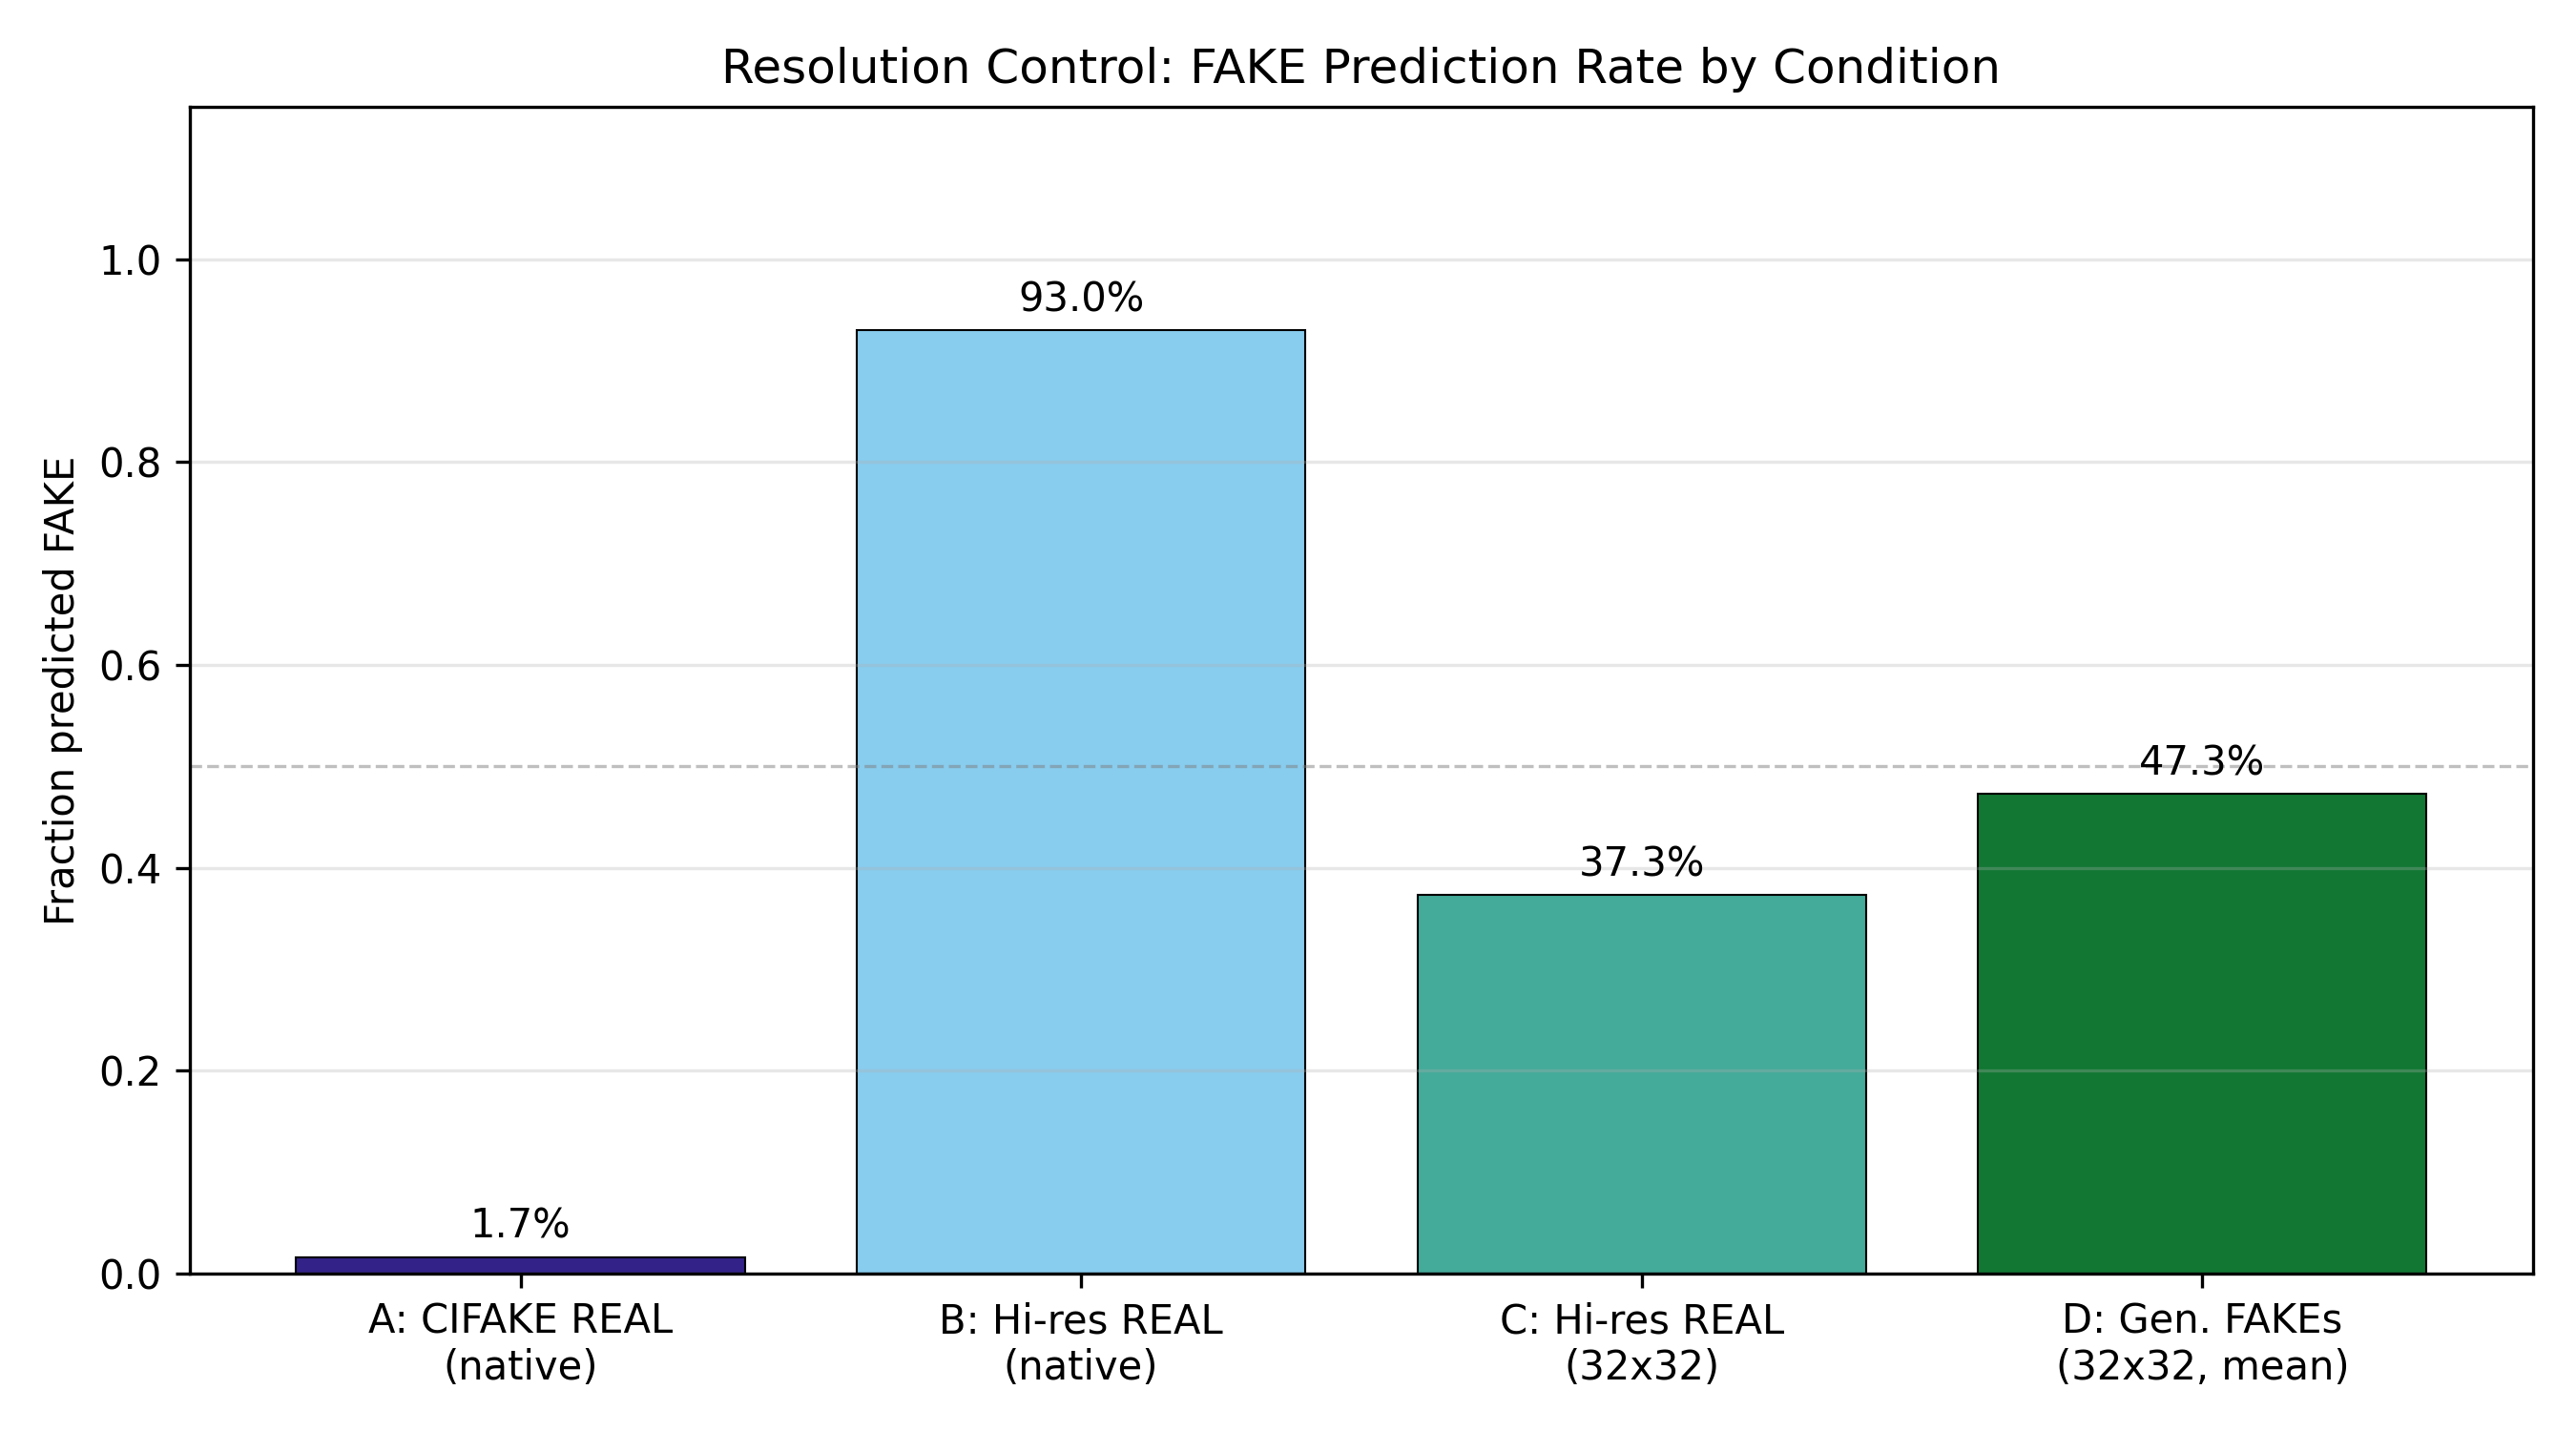


--- p_fake_distributions.png ---


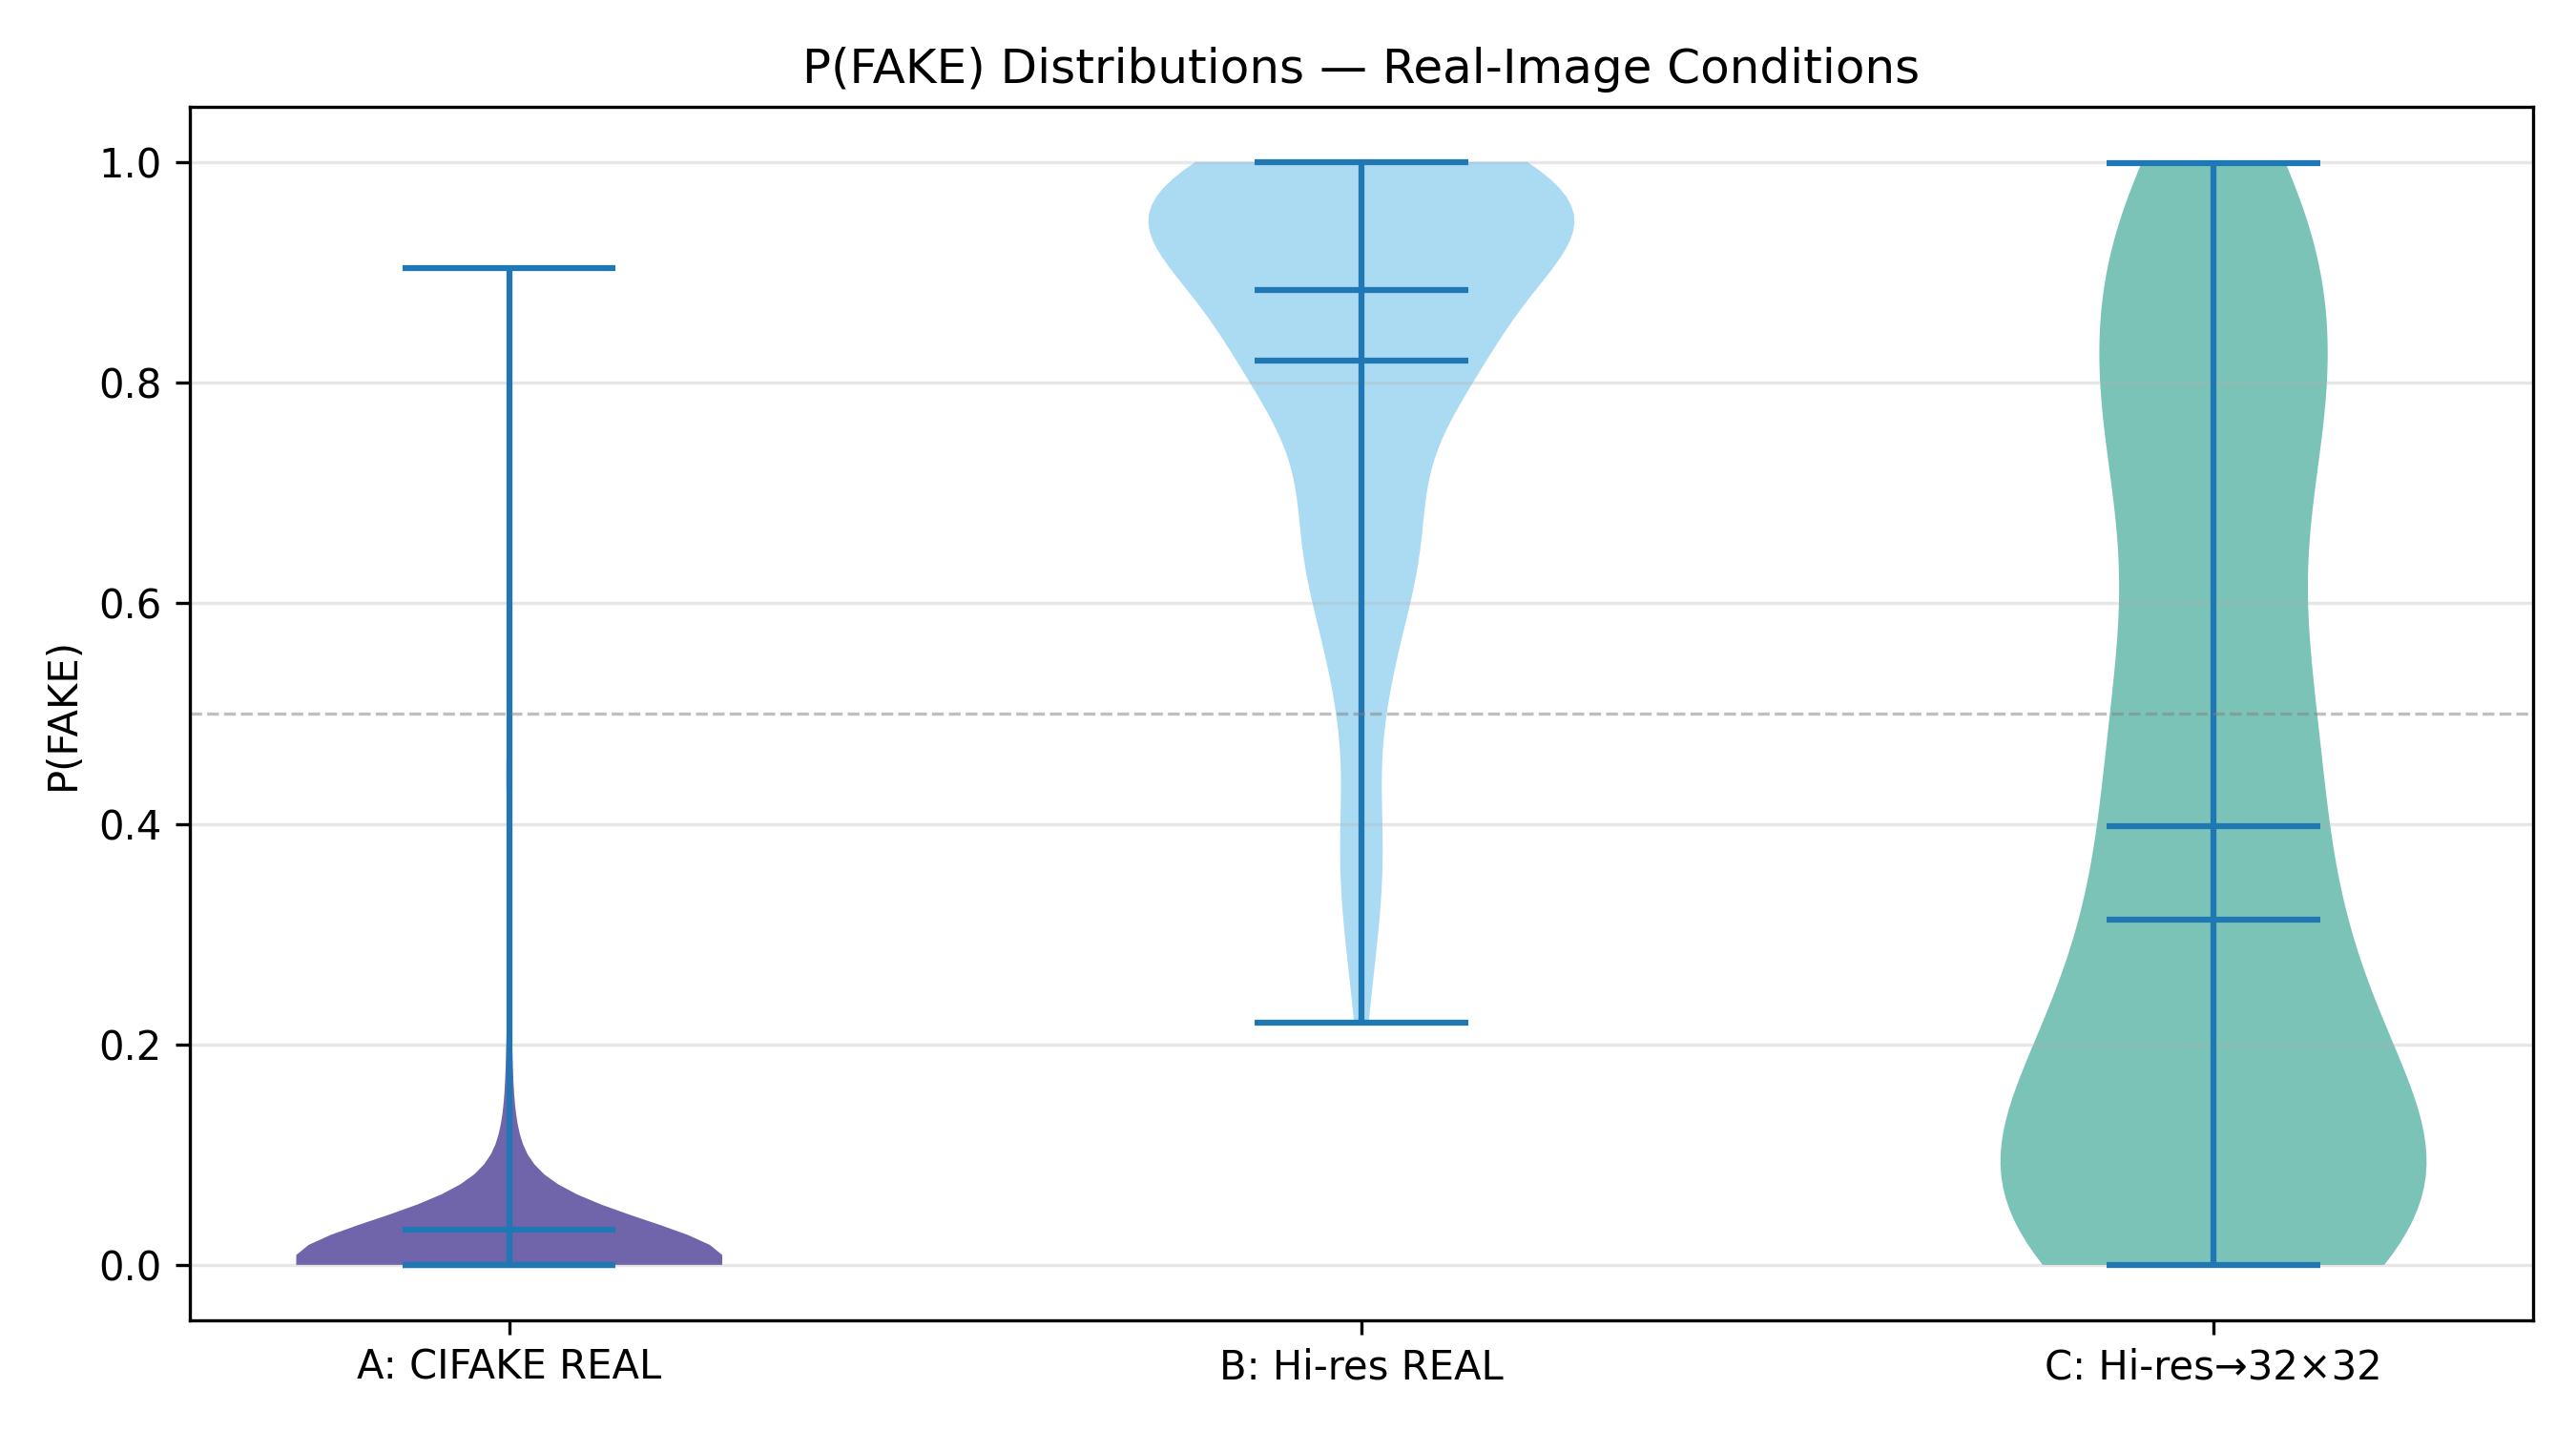


--- before_after_resolution_matching.png ---


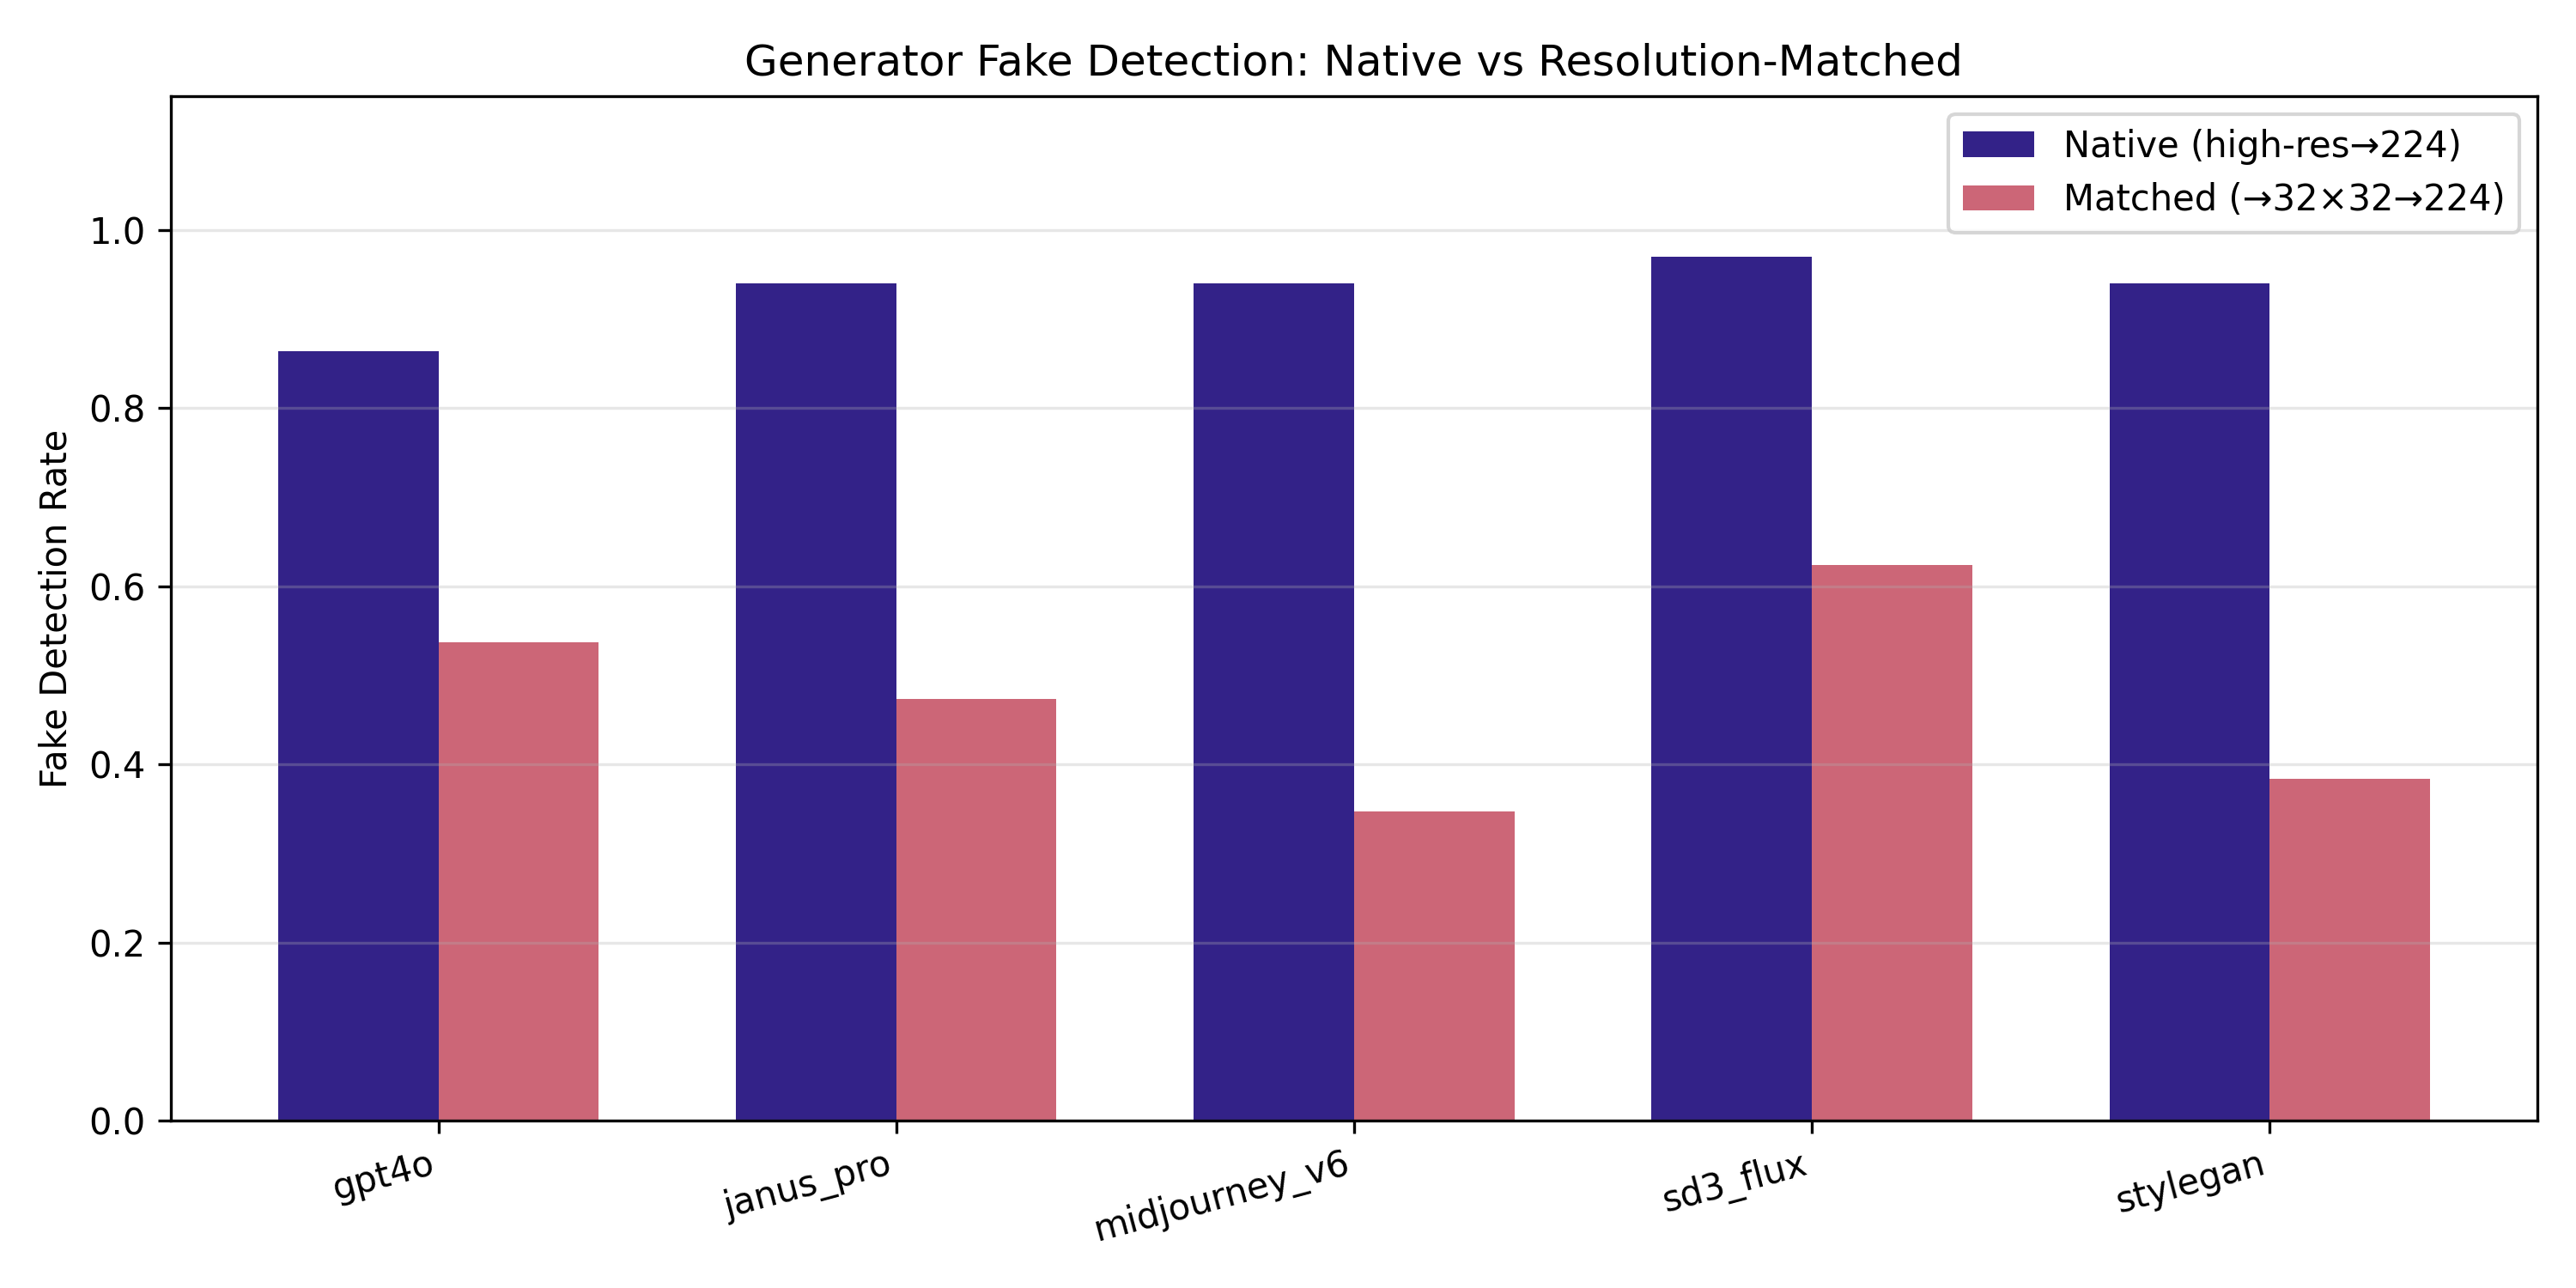


RESOLUTION CONTROL COMPLETE
Results JSON: /content/drive/MyDrive/ai-image-detection/outputs/results/resolution_control.json
Plots:        /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control

Copy these files into the local repo under outputs/ before writing the final report.


In [10]:
# Cell 8 — Display saved plots
from IPython.display import Image as IPImage, display

plots_dir = os.path.join(OUTPUT_DIR, "plots", "resolution_control")
for name in [
    "fake_rate_by_condition.png",
    "p_fake_distributions.png",
    "before_after_resolution_matching.png",
]:
    path = os.path.join(plots_dir, name)
    print(f"\n--- {name} ---")
    if os.path.exists(path):
        display(IPImage(filename=path, width=700))
    else:
        print(f"  Missing: {path}")

print("\n" + "=" * 60)
print("RESOLUTION CONTROL COMPLETE")
print("=" * 60)
print(f"Results JSON: {os.path.join(OUTPUT_DIR, 'results', 'resolution_control.json')}")
print(f"Plots:        {plots_dir}")
print("\nCopy these files into the local repo under outputs/ before writing the final report.")


# 07 — Resolution-Matched Control Experiment

**Milestone 6** (August 11–28, 2026)

This notebook tests whether the cross-generator evaluation results are confounded by
resolution differences between CIFAKE (32×32 upscaled) and generator families (high-res
downscaled).

**Design:** A 2×2 grid over `{real, fake} × {native pipeline, force-to-32×32 pipeline}`:
- **A** CIFAKE REAL, standard eval pipeline (reference)
- **B** High-res real photos, standard eval pipeline (tests false-positive rate)
- **C** High-res real photos, force-to-32×32 pipeline (isolates resolution)
- **D** Generator fakes, force-to-32×32 pipeline (tests detection at matched resolution)

## 0. CIFAKE Setup

In [11]:
# Cell 1 — Mount Google Drive & define paths
import os
from google.colab import drive

drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/MyDrive/ai-image-detection"
DATA_DIR   = os.path.join(DRIVE_BASE, "data/raw/cifake")
CHECKPOINT_DIR = os.path.join(DRIVE_BASE, "checkpoints")

# Clone repo
if not os.path.exists("/content/ai-image-detection"):
    !git clone https://github.com/krishi-shah/ai-image-detection.git /content/ai-image-detection
os.chdir("/content/ai-image-detection")

print(f"Working directory: {os.getcwd()}")
print(f"Data directory:    {DATA_DIR}")
print(f"Checkpoint dir:    {CHECKPOINT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/ai-image-detection
Data directory:    /content/drive/MyDrive/ai-image-detection/data/raw/cifake
Checkpoint dir:    /content/drive/MyDrive/ai-image-detection/checkpoints


In [12]:
# Cell 2 — Install dependencies
!pip install -q -r requirements.txt

In [14]:
# Cell 3 — Extract CIFAKE from zip uploaded to Google Drive
import os, zipfile, glob

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(os.path.join(DATA_DIR, "train")):
    zip_patterns = [
        os.path.join(DRIVE_BASE, "archive*.zip"),
        os.path.join(DRIVE_BASE, "cifake*.zip"),
    ]
    zip_path = None
    for pat in zip_patterns:
        matches = sorted(glob.glob(pat))
        if matches:
            zip_path = matches[-1]
            break

    if zip_path:
        print(f"Found zip: {zip_path}")
        print("Extracting (this takes ~1-2 minutes)...")
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DATA_DIR)
        print("Extraction complete.")
    else:
        print("ERROR: No CIFAKE zip found on Drive.")
        print("Upload archive.zip to:", DRIVE_BASE)

print(f"Contents of DATA_DIR: {os.listdir(DATA_DIR)}")

Contents of DATA_DIR: ['test', 'train']


## 1. Load Model

In [15]:
import sys
import json
import torch

IN_COLAB = 'google.colab' in sys.modules
DRIVE_BASE_PATH = DRIVE_BASE if IN_COLAB else None

REAL_REFERENCE_DIR = os.path.join(DATA_DIR, 'test', 'REAL')
GEN_DATA_DIR = os.path.join(DRIVE_BASE, 'data/generalisation') if IN_COLAB else 'data/generalisation'
CONTROLS_DIR = os.path.join(DRIVE_BASE, 'data/generalisation/_controls') if IN_COLAB else 'data/generalisation/_controls'
OUTPUT_DIR = os.path.join(DRIVE_BASE, 'outputs') if IN_COLAB else 'outputs'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

from src.model.detector import build_detector, load_checkpoint

CHECKPOINT_PATH = os.path.join(CHECKPOINT_DIR, 'best_detector.pth')
model = build_detector(pretrained=False)
load_checkpoint(model, CHECKPOINT_PATH)
model = model.to(device)
model.eval()

# Load baseline results for temperature
BASELINE_PATH = os.path.join(OUTPUT_DIR, 'results', 'baseline_results.json')
with open(BASELINE_PATH) as f:
    baseline_results = json.load(f)
TEMPERATURE = baseline_results.get('temperature', 1.0)

print(f"Model loaded. Baseline accuracy: {baseline_results['test_accuracy']}")
print(f"Temperature: {TEMPERATURE}")

Device: cuda
Model loaded. Baseline accuracy: 0.9696
Temperature: 1.2189


## 2. Download Real Control Images

Download 300 high-resolution real photographs from each source:
- COCO 2017 validation (primary control)
- Defactify real images (matched source for SD3/Flux and Midjourney)
- CommunityForensics real images (matched source for StyleGAN)

In [18]:
from scripts.download_real_controls import download_all_controls

control_results = download_all_controls(
    output_dir="data/generalisation/_controls",  # or your CONTROLS_DIR path
    n=300,
    seed=42,
)

Output directory: /content/ai-image-detection/data/generalisation/_controls
Target: 300 images per control set, seed=42

--- COCO 2017 Real ---
  [coco_real] Downloading 300 images from detection-datasets/coco...


Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

coco_real:  60%|█████▉    | 899/1500 [00:12<00:08, 71.45it/s] 


  [coco_real] Saved 300 images.

--- Defactify Real ---
  [defactify_real] Downloading 300 real images from Defactify_Image_Dataset...


defactify_real: 5386it [01:03, 84.48it/s] 


  [defactify_real] Saved 300 images.

--- CommunityForensics Real ---
  [communityforensics_real] Downloading 300 real images...


Resolving data files:   0%|          | 0/413 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/413 [00:00<?, ?it/s]

communityforensics_real: 1893it [01:13, 25.61it/s]


  [communityforensics_real] Saved 300 images.

Manifest written to: data/generalisation/_controls/manifest.json
CONTROL DOWNLOAD SUMMARY
  coco_real                      |  300 | OK
  defactify_real                 |  300 | OK
  communityforensics_real        |  300 | OK


In [19]:
# Verify downloads
from pathlib import Path
controls_root = Path(CONTROLS_DIR)
print("\nControl image counts:")
for source_dir in sorted(controls_root.iterdir()):
    if source_dir.is_dir():
        real_dir = source_dir / 'REAL'
        if real_dir.exists():
            count = sum(1 for f in real_dir.iterdir() if f.suffix.lower() in {'.png', '.jpg', '.jpeg'})
            print(f"  {source_dir.name:30s} | {count} images")


Control image counts:
  coco_real                      | 300 images
  communityforensics_real        | 300 images
  defactify_real                 | 300 images


## 3. Run Resolution Control Experiment

Run the 2×2 grid using COCO real photographs as the primary high-resolution control.

In [20]:
from src.analysis.resolution_control import run_resolution_control
from src.utils.data_loader import discover_generator_families

# Identify generator family FAKE directories
family_dirs = discover_generator_families(GEN_DATA_DIR)
generator_fake_dirs = {}
for fdir in family_dirs:
    family_name = Path(fdir).name
    fake_subdir = Path(fdir) / 'FAKE'
    if fake_subdir.exists():
        generator_fake_dirs[family_name] = str(fake_subdir)

print(f"Generator families: {list(generator_fake_dirs.keys())}")
print(f"CIFAKE REAL reference: {REAL_REFERENCE_DIR}")

# Use COCO as primary high-res real control
HIRES_REAL_DIR = str(controls_root / 'coco_real' / 'REAL')
print(f"High-res real control: {HIRES_REAL_DIR}")

Generator families: ['gpt4o', 'janus_pro', 'midjourney_v6', 'sd3_flux', 'stylegan']
CIFAKE REAL reference: /content/drive/MyDrive/ai-image-detection/data/raw/cifake/test/REAL
High-res real control: /content/drive/MyDrive/ai-image-detection/data/generalisation/_controls/coco_real/REAL


In [22]:
results = run_resolution_control(
    model=model,
    device=device,
    cifake_real_dir=REAL_REFERENCE_DIR,          # CIFAKE test/REAL
    hires_real_dir=HIRES_REAL_DIR,               # e.g. .../_controls/coco_real/REAL
    generator_fake_dirs=generator_fake_dirs,     # dict name -> FAKE folder
    temperature=TEMPERATURE,
    n_images=300,
    batch_size=32,
    output_dir=OUTPUT_DIR,
)


=== Condition A: CIFAKE REAL (native) ===


Evaluating A_cifake_real_native:   0%|          | 0/10 [00:00<?, ?it/s]


=== Condition B: High-res REAL (native) ===


Evaluating B_hires_real_native:   0%|          | 0/10 [00:00<?, ?it/s]


=== Condition C: High-res REAL (forced 32x32) ===


...

Evaluating janus_pro_native:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating midjourney_v6_native:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating sd3_flux_native:   0%|          | 0/10 [00:00<?, ?it/s]

Evaluating stylegan_native:   0%|          | 0/10 [00:00<?, ?it/s]


Results saved to: /content/drive/MyDrive/ai-image-detection/outputs/results/resolution_control.json
  Plot saved: /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/fake_rate_by_condition.png
  Plot saved: /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/p_fake_distributions.png
  Plot saved: /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/before_after_resolution_matching.png


## 4. Results Summary

In [24]:
import pandas as pd
from IPython.display import display

conds = results["conditions"]
rows = [
    {
        "Condition": "A: CIFAKE REAL (native)",
        "True label": "REAL",
        "N": conds["A_cifake_real_native"]["n_images"],
        "FAKE-rate": conds["A_cifake_real_native"]["fake_rate"],
        "Mean P(FAKE)": conds["A_cifake_real_native"]["mean_p_fake"],
        "Median P(FAKE)": conds["A_cifake_real_native"]["median_p_fake"],
    },
    {
        "Condition": "B: Hi-res REAL (native)",
        "True label": "REAL",
        "N": conds["B_hires_real_native"]["n_images"],
        "FAKE-rate": conds["B_hires_real_native"]["fake_rate"],
        "Mean P(FAKE)": conds["B_hires_real_native"]["mean_p_fake"],
        "Median P(FAKE)": conds["B_hires_real_native"]["median_p_fake"],
    },
    {
        "Condition": "C: Hi-res REAL (→32×32)",
        "True label": "REAL",
        "N": conds["C_hires_real_matched"]["n_images"],
        "FAKE-rate": conds["C_hires_real_matched"]["fake_rate"],
        "Mean P(FAKE)": conds["C_hires_real_matched"]["mean_p_fake"],
        "Median P(FAKE)": conds["C_hires_real_matched"]["median_p_fake"],
    },
]

for fam, r in sorted(conds.get("D_generator_fakes_matched", {}).items()):
    rows.append({
        "Condition": f"D: {fam} FAKE (→32×32)",
        "True label": "FAKE",
        "N": r["n_images"],
        "FAKE-rate": r["fake_rate"],
        "Mean P(FAKE)": r["mean_p_fake"],
        "Median P(FAKE)": r["median_p_fake"],
    })

df = pd.DataFrame(rows)
display(df.style.format({
    "FAKE-rate": "{:.1%}",
    "Mean P(FAKE)": "{:.4f}",
    "Median P(FAKE)": "{:.4f}",
}).hide(axis="index"))

interp = results["interpretation"]
print("\n=== INTERPRETATION ===")
print(f"  A FAKE-rate: {interp['A_cifake_real_fake_rate']:.1%}")
print(f"  B FAKE-rate: {interp['B_hires_real_fake_rate']:.1%}")
print(f"  C FAKE-rate: {interp['C_hires_real_matched_fake_rate']:.1%}")
print(f"  Confound suspected: {interp['resolution_confound_suspected']}")
print(f"\n  {interp['summary']}")

Condition,True label,N,FAKE-rate,Mean P(FAKE),Median P(FAKE)
A: CIFAKE REAL (native),REAL,300,1.7%,0.0318,0.0004
B: Hi-res REAL (native),REAL,300,93.0%,0.8203,0.8839
C: Hi-res REAL (→32×32),REAL,300,37.3%,0.3979,0.3134
D: gpt4o FAKE (→32×32),FAKE,300,53.7%,0.5270,0.5287
D: janus_pro FAKE (→32×32),FAKE,300,47.3%,0.4902,0.4782
D: midjourney_v6 FAKE (→32×32),FAKE,300,34.7%,0.3972,0.3485
D: sd3_flux FAKE (→32×32),FAKE,300,62.3%,0.5950,0.6243
D: stylegan FAKE (→32×32),FAKE,300,38.3%,0.4116,0.3591



=== INTERPRETATION ===
  A FAKE-rate: 1.7%
  B FAKE-rate: 93.0%
  C FAKE-rate: 37.3%
  Confound suspected: True

  High false-positive rate on high-resolution reals suggests the detector partly relies on resolution/resampling cues.


In [27]:
# LaTeX table for final report
print("\n--- LaTeX table ---\n")
print(df.to_latex(index=False, escape=True))


--- LaTeX table ---

\begin{tabular}{llrrrr}
\toprule
Condition & True label & N & FAKE-rate & Mean P(FAKE) & Median P(FAKE) \\
\midrule
A: CIFAKE REAL (native) & REAL & 300 & 0.016667 & 0.031807 & 0.000394 \\
B: Hi-res REAL (native) & REAL & 300 & 0.930000 & 0.820317 & 0.883858 \\
C: Hi-res REAL (→32×32) & REAL & 300 & 0.373333 & 0.397922 & 0.313387 \\
D: gpt4o FAKE (→32×32) & FAKE & 300 & 0.536667 & 0.526974 & 0.528743 \\
D: janus\_pro FAKE (→32×32) & FAKE & 300 & 0.473333 & 0.490219 & 0.478237 \\
D: midjourney\_v6 FAKE (→32×32) & FAKE & 300 & 0.346667 & 0.397226 & 0.348503 \\
D: sd3\_flux FAKE (→32×32) & FAKE & 300 & 0.623333 & 0.594957 & 0.624299 \\
D: stylegan FAKE (→32×32) & FAKE & 300 & 0.383333 & 0.411565 & 0.359090 \\
\bottomrule
\end{tabular}



## 5. Visualisations


--- fake_rate_by_condition.png ---


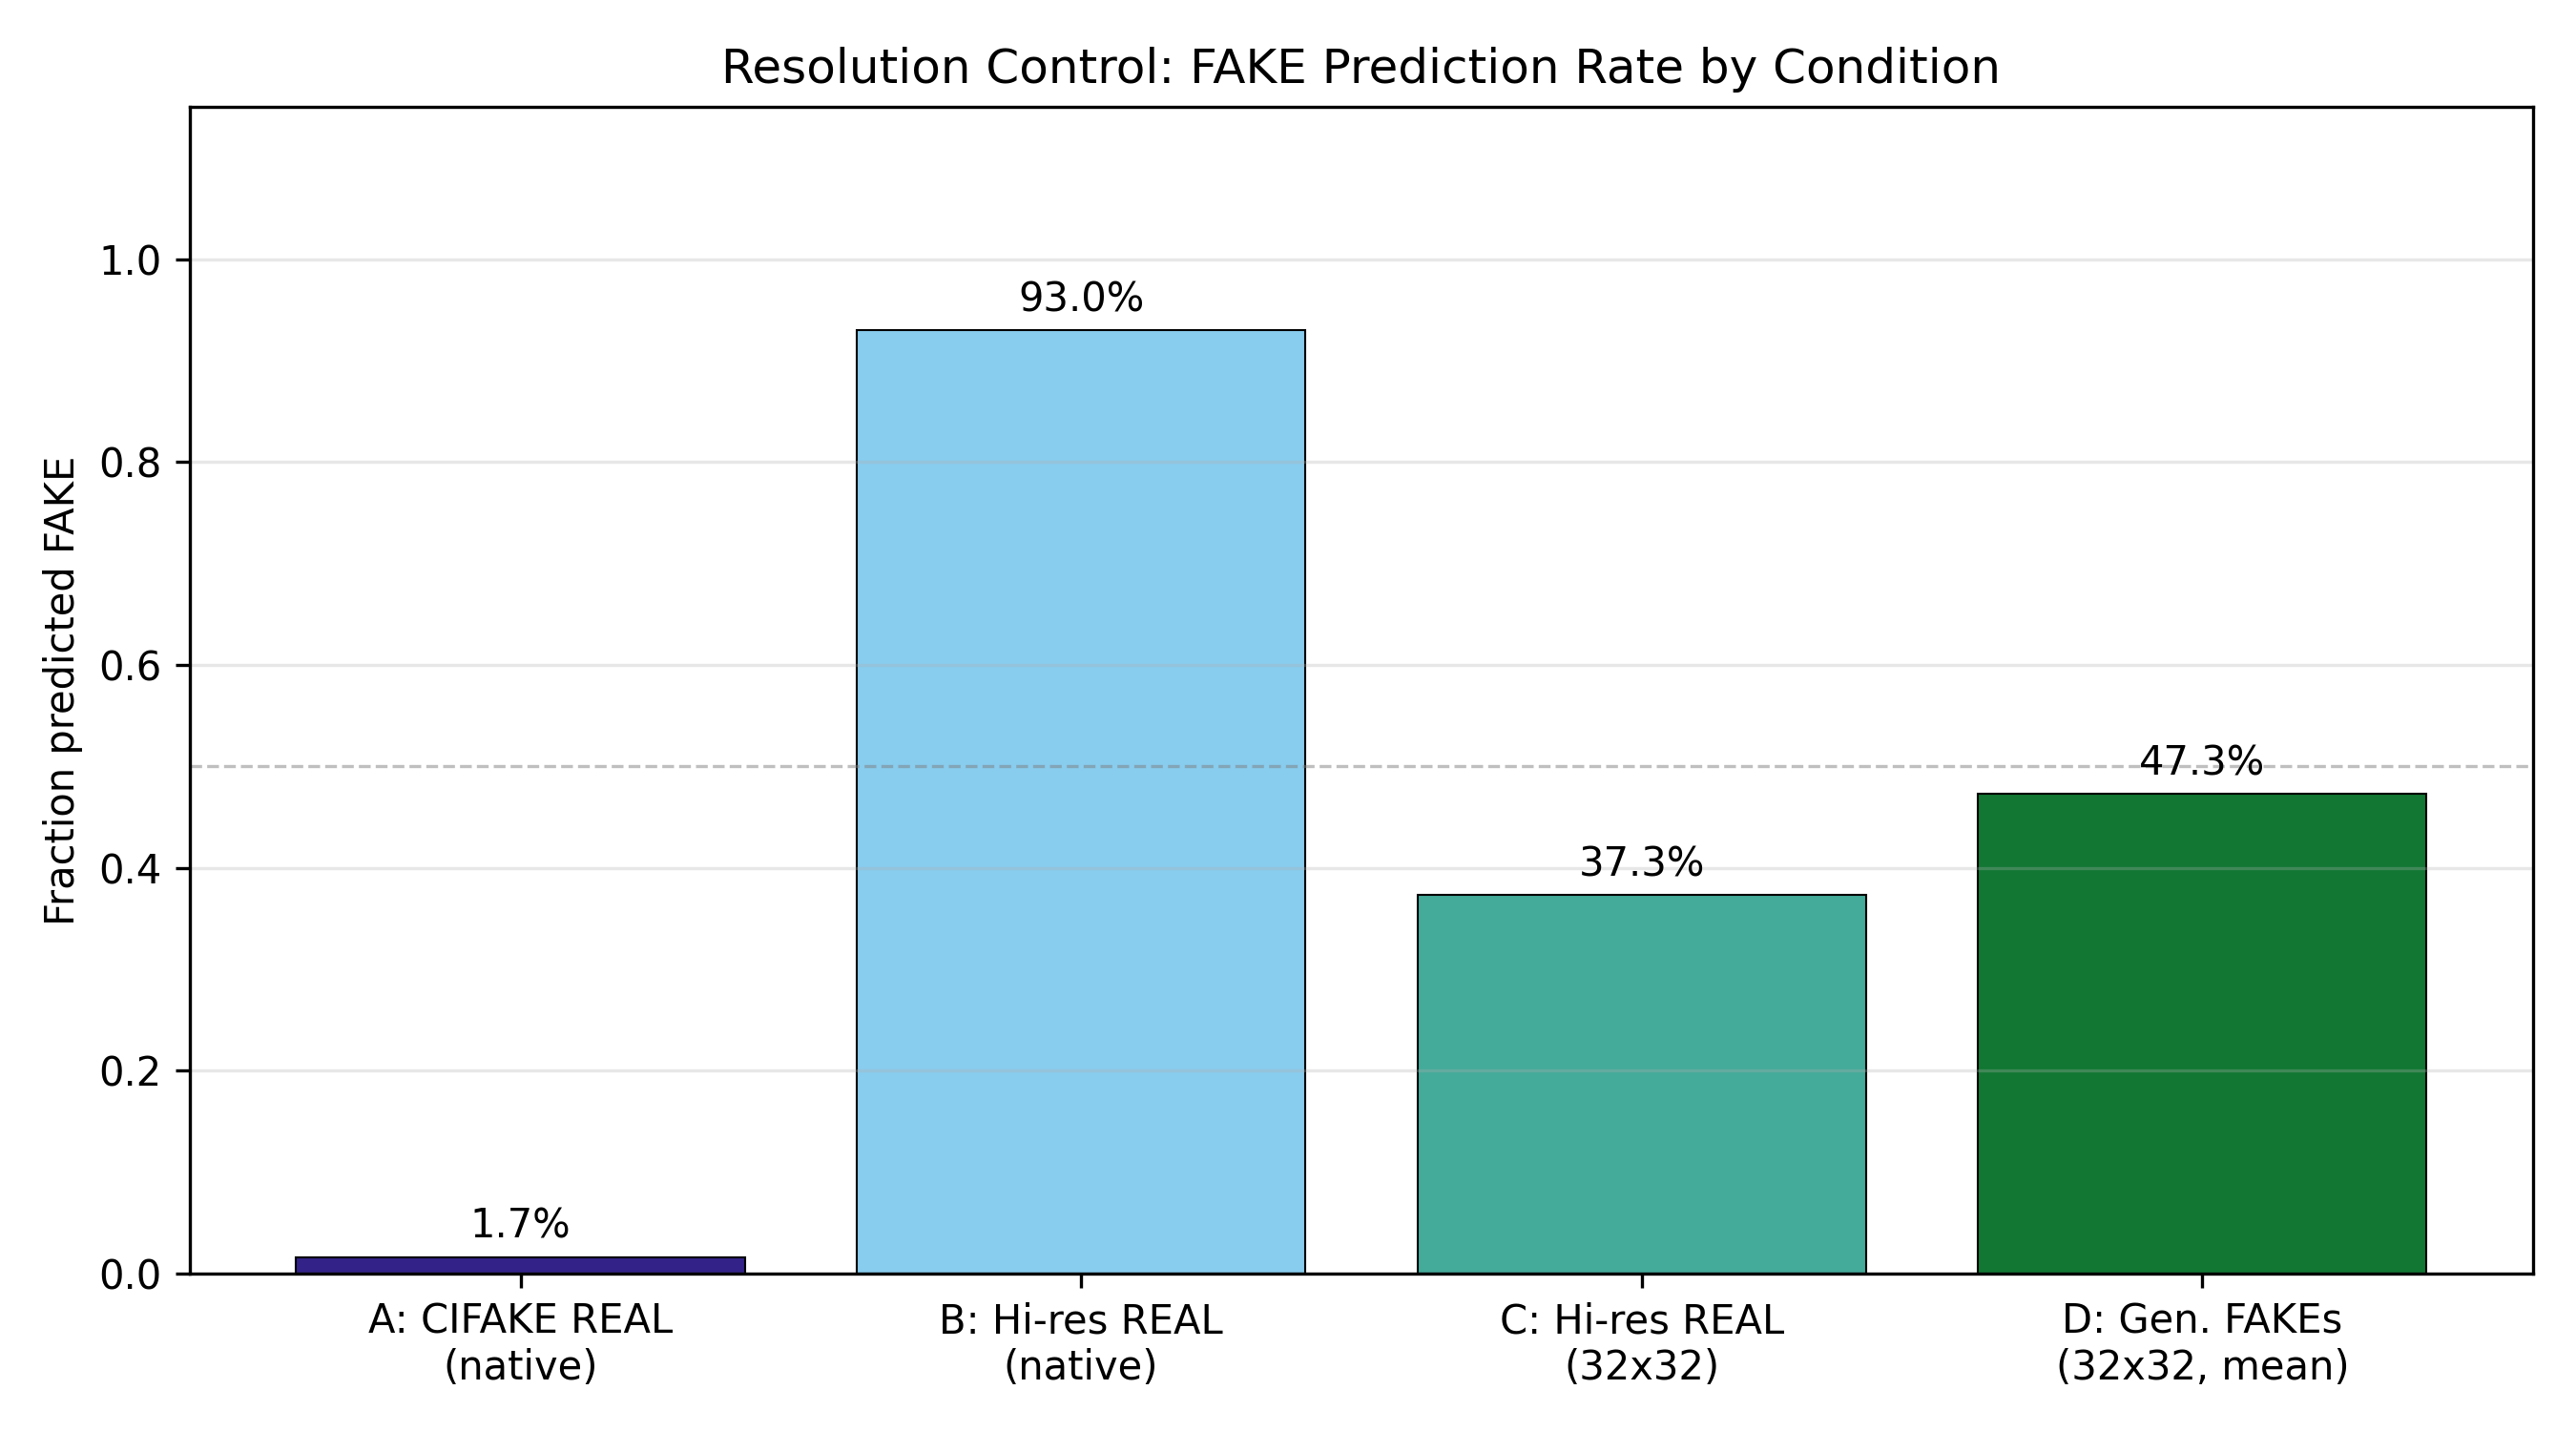


--- p_fake_distributions.png ---


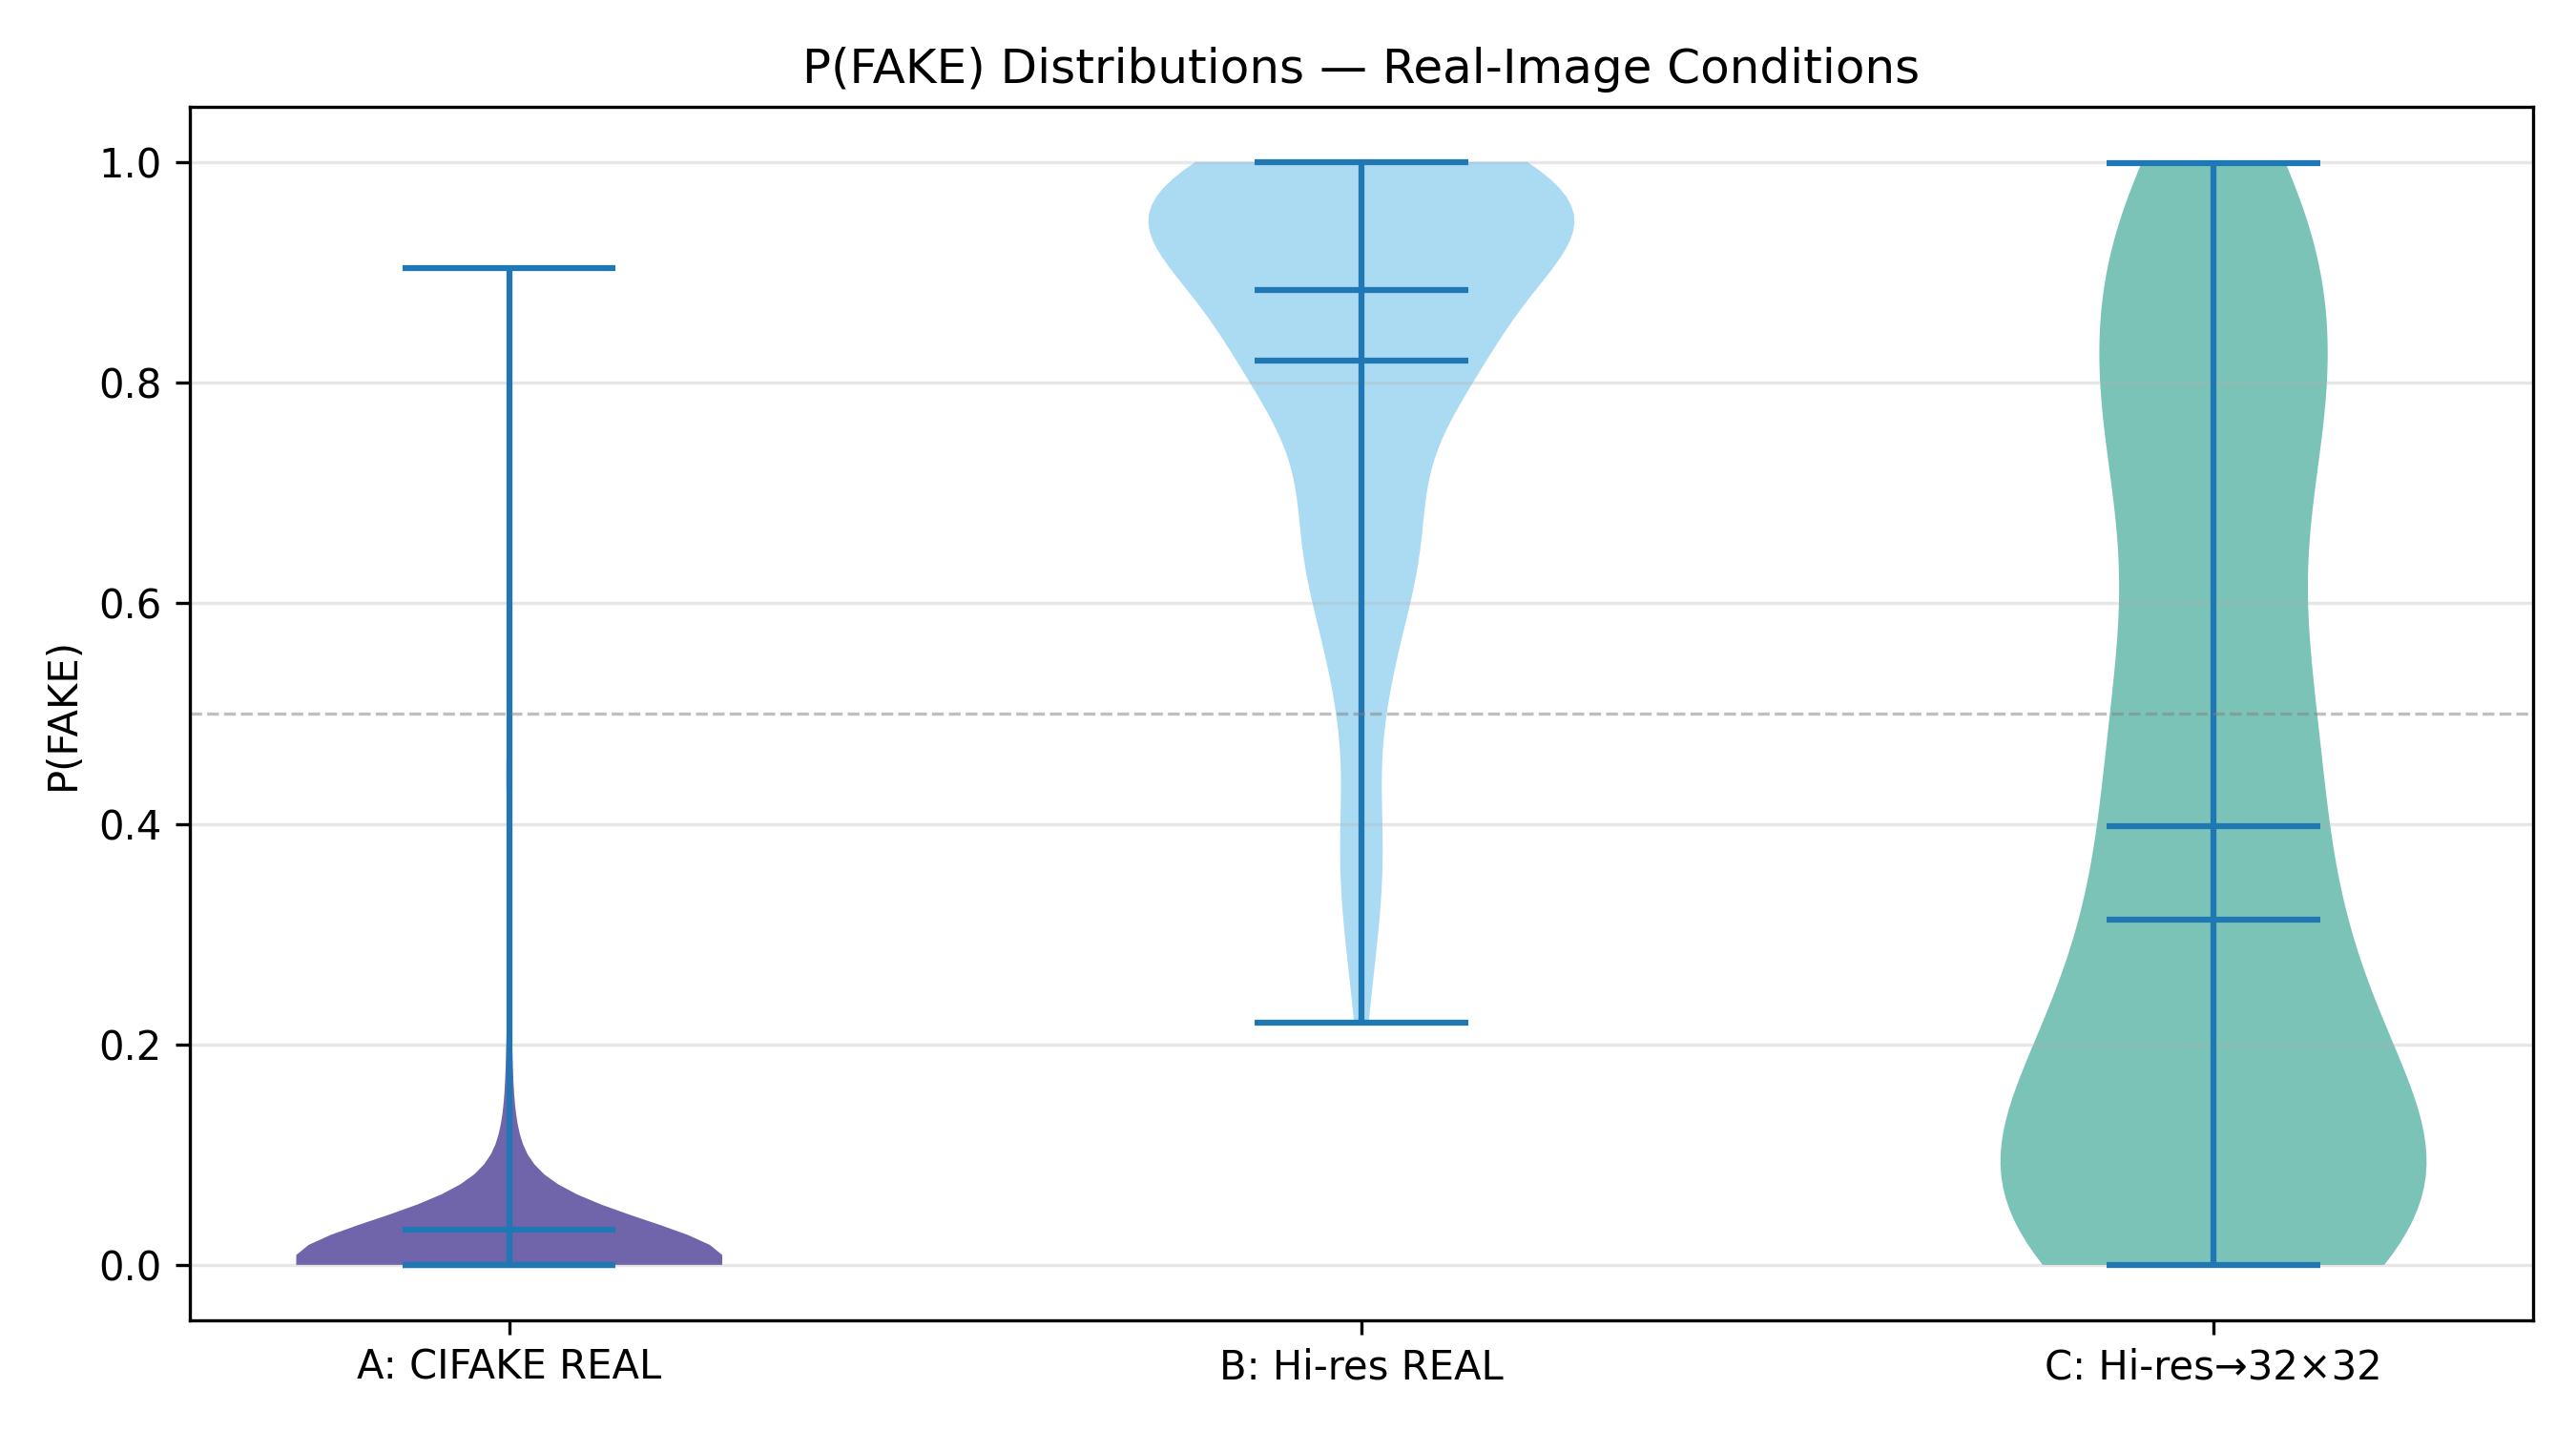

In [28]:
from IPython.display import Image as IPImage, display as ipdisplay
import os

plots_dir = os.path.join(OUTPUT_DIR, 'plots', 'resolution_control')
for plot_name in [
    'fake_rate_by_condition.png',
    'p_fake_distributions.png',
    'family_resolution_comparison.png',
]:
    path = os.path.join(plots_dir, plot_name)
    if os.path.exists(path):
        print(f"\n--- {plot_name} ---")
        ipdisplay(IPImage(filename=path))

## 6. Matched-Source Controls (Optional)

Re-run conditions B and C using the matched-source real images from Defactify
and CommunityForensics (if available) for a tighter domain control.

In [29]:
from src.analysis.resolution_control import evaluate_condition, get_native_eval_transform, get_matched_lowres_transform

matched_results = {}
native_tf = get_native_eval_transform()
lowres_tf = get_matched_lowres_transform()

for source_name in ['defactify_real', 'communityforensics_real']:
    real_dir = str(controls_root / source_name / 'REAL')
    if not os.path.exists(real_dir) or len(os.listdir(real_dir)) == 0:
        print(f"Skipping {source_name} (not available)")
        continue

    print(f"\n=== {source_name} ===")

    # Native pipeline
    r_native = evaluate_condition(
        model, real_dir, true_label=1, transform=native_tf,
        device=device, temperature=TEMPERATURE, max_images=300,
    )
    print(f"  Native pipeline:  FAKE-rate = {r_native['fake_rate']:.3f}, Mean P(FAKE) = {r_native['mean_p_fake']:.4f}")

    # Force-to-32x32 pipeline
    r_lowres = evaluate_condition(
        model, real_dir, true_label=1, transform=lowres_tf,
        device=device, temperature=TEMPERATURE, max_images=300,
    )
    print(f"  Force-32x32:      FAKE-rate = {r_lowres['fake_rate']:.3f}, Mean P(FAKE) = {r_lowres['mean_p_fake']:.4f}")

    matched_results[f"{source_name}_native"] = r_native
    matched_results[f"{source_name}_lowres"] = r_lowres


=== defactify_real ===


Evaluating unknown:   0%|          | 0/10 [00:00<?, ?it/s]

  Native pipeline:  FAKE-rate = 0.957, Mean P(FAKE) = 0.8436


Evaluating unknown:   0%|          | 0/10 [00:00<?, ?it/s]

  Force-32x32:      FAKE-rate = 0.277, Mean P(FAKE) = 0.3240

=== communityforensics_real ===


Evaluating unknown:   0%|          | 0/10 [00:00<?, ?it/s]

  Native pipeline:  FAKE-rate = 0.717, Mean P(FAKE) = 0.6649


Evaluating unknown:   0%|          | 0/10 [00:00<?, ?it/s]

  Force-32x32:      FAKE-rate = 0.217, Mean P(FAKE) = 0.2450


## 7. Discussion

**Interpretation guide:**

- If Condition B (high-res REAL, native pipeline) shows a **high** false-positive rate,
  the detector is biased by resolution — it misclassifies high-res real images as FAKE
  because it learned resolution-dependent features from CIFAKE's 32×32 images.

- If Condition B shows a **low** false-positive rate (comparable to Condition A),
  the detector genuinely transfers across resolutions and the cross-generator results
  are not confounded.

- Condition D reveals whether fake detection survives when the resolution advantage
  is removed by forcing fakes through the same 32×32 bottleneck as CIFAKE.

In [30]:
print("\n" + "="*60)
print("RESOLUTION CONTROL COMPLETE")
print("="*60)
print(f"\nResults: {os.path.join(OUTPUT_DIR, 'results', 'resolution_control.json')}")
print(f"Plots:   {os.path.join(OUTPUT_DIR, 'plots', 'resolution_control', '')}")


RESOLUTION CONTROL COMPLETE

Results: /content/drive/MyDrive/ai-image-detection/outputs/results/resolution_control.json
Plots:   /content/drive/MyDrive/ai-image-detection/outputs/plots/resolution_control/
